# Testbench for `max_pool1d_w4()`

In [12]:
#
# Copyright (C) 2024, Advanced Micro Devices, Inc. All rights reserved.
# SPDX-License-Identifier: MIT
#
# Author: Faisal El-Shabani

In [1]:
from tensorflow import keras
from tensorflow.keras.layers import Conv1D, MaxPooling1D
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import h5py as h5
import numpy as np
import os.path
import vfs
import varray as va

NITERATIONS = 4    # Number of AI Engine graph iterations

2025-08-22 07:49:24.063571: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-22 07:49:24.067766: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-22 07:49:24.077178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755870564.091840 3975565 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755870564.096489 3975565 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755870564.109728 3975565 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Layer Definition

In [2]:
inputs = keras.Input(shape=(1024,2),name="input")
x1 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1d_w1",activation='relu')(inputs)
x2 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w2")(x1)
outputs = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1d_w3",activation='relu')(x2)
model_stim = keras.Model(inputs=inputs,outputs=outputs)
w1_weights = np.loadtxt('../conv1d_w1/w1_weights_trained.txt')
w1_weights = (w1_weights.astype("bfloat16")).astype("float32")
w1_bias = np.loadtxt('../conv1d_w1/w1_bias_trained.txt')
w1_bias = (w1_bias.astype("bfloat16")).astype("float32")
w1_weights = np.reshape(w1_weights,(7,2,64))
w3_weights = np.loadtxt('../conv1d_template/w3_weights_trained.txt')
w3_weights = (w3_weights.astype("bfloat16")).astype("float32")
w3_bias = np.loadtxt('../conv1d_template/w3_bias_trained.txt')
w3_bias = (w3_bias.astype("bfloat16")).astype("float32")
w3_weights = np.reshape(w3_weights,(7,64,64))
model_stim.get_layer("conv1d_w3").set_weights((w3_weights,w3_bias))

2025-08-22 07:49:32.554452: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
model_stim.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_w1 (Conv1D)              │ (None, 1024, 64)       │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w2 (MaxPooling1D)    │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_w3 (Conv1D)              │ (None, 512, 64)        │        28,736 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,696 (116.00 KB)

 Trainable params: 29,696 (116.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
inputs = keras.Input(shape=(512,64),name="input_layer")
outputs = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w4")(inputs)
model = keras.Model(inputs=inputs,outputs=outputs)

In [5]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w4 (MaxPooling1D)    │ (None, 256, 64)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Read training and test data

In [6]:
if not("RADIOML_DATA" in os.environ):
    print("Please set environment variable RADIOML_DATA to point to dataset found in https://www.kaggle.com/datasets/pinxau1000/radioml2018")
data_file = os.environ["RADIOML_DATA"] + 'GOLD_XYZ_OSC.0001_1024.hdf5'
file_handle = h5.File(data_file,'r')
myData = file_handle['X'][:]  #1024x2 samples 
myMods = file_handle['Y'][:]  #mods 
mySNRs = file_handle['Z'][:]  #snrs  
file_handle.close()
X_train ,X_predict ,Y_train ,Y_test, Z_train, Z_test =train_test_split(myData, myMods, mySNRs, test_size=0.2, random_state=0)
X_predict = X_predict[:NITERATIONS]
X_predict = (X_predict.astype("bfloat16")).astype("float32")
X_inputs = model_stim.predict(X_predict,batch_size=1024)
X_inputs = (X_inputs.astype("bfloat16")).astype("float32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


## Compute Golden Outputs

In [7]:
predict = model.predict(X_inputs, batch_size=1024)
predict = (predict.astype("bfloat16")).astype("float32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


## Store Layer Inputs

In [ ]:
# Create directory if it doesn't exist
data_i = X_inputs
if not os.path.exists('data'):
    os.makedirs('data')
np.savetxt('data/data_i.txt',np.reshape(data_i,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(X_inputs.shape)
print(data_i.shape)


(4, 512, 64)
(4, 512, 64)


## Store Layer Outputs

In [ ]:
data_o = predict

np.savetxt('data/data_o.txt',np.reshape(data_o,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(data_o.shape)

(4, 256, 64)


## Run Vitis Functional Simulation

In [10]:
max_pool1d_w4_graph = vfs.aieGraph(
    input_file='max_pool1d_w4_app.cpp',
    part="xc2ve3858-ssva2112-2MP-e-S",
    include_paths=['./','../utility'])
act_o = max_pool1d_w4_graph.run(va.array(np.reshape(data_i,(1,-1)),dtype=va.bfloat16))
act_o = np.array(act_o)



Compiling AIE Graph
Compilation directory: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/max_pool1d_template/vfs_work/max_pool1d_w4_app_8ac1a6e3
Compilation command: v++ -c --mode aie --config vfs_work/max_pool1d_w4_app_8ac1a6e3/max_pool1d_w4_app.cfg --work_dir vfs_work/max_pool1d_w4_app_8ac1a6e3/Work --output vfs_work/max_pool1d_w4_app_8ac1a6e3/libadf.a --target x86sim
Writing log to: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/max_pool1d_template/vfs_work/max_pool1d_w4_app_8ac1a6e3/Work/logs/aie_x86sim.log
Please wait ...

Compilation finished successfully.
Loaded AIEGraph


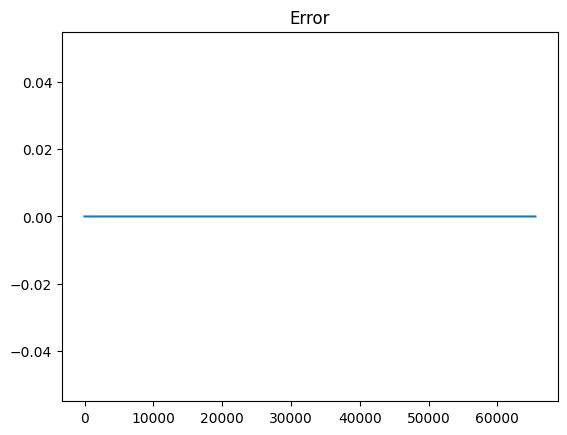

In [11]:
data_o_reshaped = np.reshape(data_o,(-1))
err = data_o_reshaped-act_o
plt.plot(err)
plt.title("Error")
plt.show()
